# Eval: Qwen2.5-VL-2B-Instruct vs Vintern-LoRA Fine-tuned

So sánh **Qwen2.5-VL-2B-Instruct** (vision-language model, có vision encoder) với **Vintern-1B-v2 LoRA Fine-tuned** trên **700 samples test**.

- Kết quả **Vintern-LoRA** load từ `debug_vintern_lora.csv` (đã eval sẵn)
- **Qwen2.5-VL-2B** eval trực tiếp trong notebook, dùng **T4 GPU**
- **Có sử dụng ảnh thật** — Qwen2.5-VL là multimodal model
- Metrics: BLEU · METEOR · ROUGE-1 · ROUGE-2 · ROUGE-L · BERTScore

> Model: `Qwen/Qwen2.5-VL-2B-Instruct` — vision-language model mạnh, hỗ trợ tiếng Việt tốt.


## Cell 1 — Cài thư viện

> Sau cell này hãy **Restart kernel** rồi chạy tiếp từ Cell 2.


In [1]:
# import subprocess, sys

# def pip(args):
#     subprocess.run([sys.executable, '-m', 'pip'] + args,
#                    check=True, capture_output=True)

# # Qwen2.5-VL yeu cau transformers >= 4.49.0 va qwen-vl-utils
# pip(['install', '-q', 'transformers>=4.49.0', '--upgrade'])
# pip(['install', '-q', 'qwen-vl-utils', 'torchvision'])
# pip(['install', '-q', 'packaging', 'datasets', 'huggingface_hub', 'hf_transfer'])
# pip(['install', '-q', 'rouge_score', 'evaluate', 'underthesea', 'bert-score', 'nltk'])
# pip(['uninstall', 'numpy', '-y'])
# pip(['install', '-q', 'numpy==1.26.4'])

# import transformers, numpy as np
# print(f'transformers : {transformers.__version__}')
# print(f'numpy        : {np.__version__}')
# print('\n✅ Done — Restart kernel truoc khi chay Cell 2!')


## Cell 2 — Config


In [2]:
from pathlib import Path
import torch, os

KAGGLE_WORKING         = Path('/kaggle/working')
SRC_DATASET            = '/kaggle/input/datasets/maituananh511/test-dataset-chart-vqa/vi_chart_dataset'
DST_DATASET            = str(KAGGLE_WORKING / 'vi_chart_dataset')
VIETNAMESE_DATA_PATH   = Path('/kaggle/input/datasets/maituananh511/data-vietnamese/Data Vietnamese')
VIETNAMESE_IMAGES_PATH = VIETNAMESE_DATA_PATH / 'images'
VIETNAMESE_JSONL_PATH  = VIETNAMESE_DATA_PATH / 'viet_chart_vqa.jsonl'

QWEN_DIR      = KAGGLE_WORKING / 'qwen2vl_model'
QWEN_REPO_ID  = 'Qwen/Qwen2-VL-2B-Instruct'
VINTERN_LORA_CSV = Path('/kaggle/input/datasets/maituananh511/700-vinternlora-result/debug_vintern_lora.csv')
# Upload CSV thu cong thi doi sang:
# VINTERN_LORA_CSV = KAGGLE_WORKING / 'debug_vintern_lora.csv'

CHART_TEST_N   = 500
VIETNAMESE_N   = 200
EVAL_TOTAL     = CHART_TEST_N + VIETNAMESE_N
# Qwen2.5-VL xu ly anh nen VRAM cao hon — giam batch neu OOM
BATCH_SIZE     = 8
MAX_NEW_TOKENS = 64
METRICS        = ['bleu', 'meteor', 'rouge1', 'rouge2', 'rougeL', 'bertscore']

# Kiem tra GPU
n_gpu = torch.cuda.device_count()
print(f'GPU count: {n_gpu}')
for i in range(n_gpu):
    p = torch.cuda.get_device_properties(i)
    print(f'  GPU {i}: {p.name} — {p.total_memory // 1024**3} GB')
print(f'\nEval target : {EVAL_TOTAL} samples')
print(f'Qwen repo   : {QWEN_REPO_ID}')


GPU count: 2
  GPU 0: Tesla T4 — 14 GB
  GPU 1: Tesla T4 — 14 GB

Eval target : 700 samples
Qwen repo   : Qwen/Qwen2-VL-2B-Instruct


## Cell 3 — Download Qwen2.5-VL-2B-Instruct


In [3]:
from huggingface_hub import snapshot_download
import shutil, os

# Xoa folder rong neu download do lan truoc
if QWEN_DIR.exists() and not any(QWEN_DIR.iterdir()):
    shutil.rmtree(str(QWEN_DIR))
    print('Xoa folder rong')

if not QWEN_DIR.exists():
    QWEN_DIR.mkdir(parents=True, exist_ok=True)
    print(f'Downloading {QWEN_REPO_ID} ...')
    snapshot_download(
        repo_id=QWEN_REPO_ID,
        local_dir=str(QWEN_DIR),
        ignore_patterns=['*.msgpack', '*.h5', 'flax_model*', 'tf_model*'],
    )
    print('Download xong')
else:
    print(f'Model da co — {len(list(QWEN_DIR.iterdir()))} files')

print('Files:', os.listdir(str(QWEN_DIR))[:10])


Model da co — 15 files
Files: ['chat_template.json', 'LICENSE', '.gitattributes', 'vocab.json', 'preprocessor_config.json', 'model.safetensors.index.json', 'tokenizer_config.json', 'tokenizer.json', 'config.json', 'model-00002-of-00002.safetensors']


## Cell 4 — Load dataset (700 samples)


In [4]:
from datasets import load_from_disk
from PIL import Image
import json, shutil, os

def is_dataset_complete(dst, src):
    if not os.path.exists(dst):
        return False
    src_files = {os.path.relpath(os.path.join(r, f), src)
                 for r, _, fs in os.walk(src) for f in fs}
    dst_files = {os.path.relpath(os.path.join(r, f), dst)
                 for r, _, fs in os.walk(dst) for f in fs}
    missing = src_files - dst_files
    if missing:
        print(f'Thieu {len(missing)} files')
        return False
    return True

if is_dataset_complete(DST_DATASET, SRC_DATASET):
    print('Dataset da copy day du, skip.')
else:
    if os.path.exists(DST_DATASET):
        shutil.rmtree(DST_DATASET)
    print('Copying dataset ...')
    shutil.copytree(SRC_DATASET, DST_DATASET)
    print('Copy xong.')

vi_chart_dataset = load_from_disk(DST_DATASET)
print(vi_chart_dataset)

vietnamese_records = []
with open(VIETNAMESE_JSONL_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            vietnamese_records.append(json.loads(line))
print(f'Vietnamese records: {len(vietnamese_records)} loaded')


Copying dataset ...
Copy xong.
DatasetDict({
    train: Dataset({
        features: ['id', 'image', 'description', 'conversations', 'groundtruth'],
        num_rows: 100002
    })
    test: Dataset({
        features: ['id', 'image', 'description', 'conversations', 'groundtruth'],
        num_rows: 500
    })
})
Vietnamese records: 4957 loaded


## Cell 5 — Build eval_dataset


In [5]:
from PIL import Image

def normalize_turn(turn):
    if isinstance(turn, str):
        return {'role': 'assistant', 'content': turn}
    if isinstance(turn, dict):
        role = turn.get('role') or turn.get('from', '')
        if role in ('human', 'user'):      role = 'user'
        elif role in ('gpt', 'assistant'): role = 'assistant'
        for rk in ('assistant', 'user', 'human', 'gpt'):
            if rk in turn and 'content' not in turn and 'role' not in turn:
                role = 'assistant' if rk in ('assistant', 'gpt') else 'user'
                return {'role': role, 'content': str(turn[rk])}
        return {'role': role, 'content': str(turn.get('content') or turn.get('value', ''))}
    return {'role': 'assistant', 'content': str(turn)}

# Chart samples — giu nguyen PIL Image
chart_test_raw   = vi_chart_dataset['test']
chart_n          = min(CHART_TEST_N, len(chart_test_raw))
chart_test_items = [chart_test_raw[i] for i in range(chart_n)]
print(f'vi_chart test   : {chart_n} samples')

# Vietnamese samples
vn_test_items = []
for record in reversed(vietnamese_records):
    if len(vn_test_items) >= VIETNAMESE_N:
        break
    img_path = VIETNAMESE_IMAGES_PATH / record['image']
    try:
        image = Image.open(img_path).convert('RGB')
    except Exception as e:
        print(f'Warning: {img_path}: {e}')
        continue
    convs = [normalize_turn(t) for t in record['conversations']]
    pairs = [(convs[i], convs[i+1]) for i in range(0, len(convs)-1, 2)]
    for idx, (q, a) in enumerate(pairs):
        if len(vn_test_items) >= VIETNAMESE_N:
            break
        rid = record['id'] if len(pairs) == 1 else f"{record['id']}_q{idx}"
        vn_test_items.append({'id': rid, 'image': image, 'conversations': [q, a]})

print(f'vietnamese test  : {len(vn_test_items)} samples')
eval_dataset = chart_test_items + vn_test_items
print(f'Total            : {len(eval_dataset)} samples')

# Kiem tra anh co san
has_img = sum(1 for x in eval_dataset if x.get('image') is not None)
print(f'Samples co anh   : {has_img} / {len(eval_dataset)}')


vi_chart test   : 500 samples


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


vietnamese test  : 200 samples
Total            : 700 samples
Samples co anh   : 700 / 700


## Cell 6 — GPU Worker (Qwen2.5-VL-2B-Instruct)

Qwen2.5-VL là **vision-language model** — xử lý cả ảnh lẫn text.

Pipeline:
- Dùng `AutoProcessor` để tokenize text + preprocess ảnh cùng lúc
- Mỗi sample truyền ảnh vào message dạng `{"type": "image", "image": pil_image}`
- Nếu sample không có ảnh, fallback về text-only
- **Batch_size=8** để tránh OOM (ảnh tốn VRAM hơn text)


In [6]:
def evaluate_qwen25vl_1gpu(eval_dataset, qwen_dir, batch_size=1, max_new_tokens=32):
    import os, gc, torch, nltk
    import pandas as pd
    from transformers import Qwen2VLForConditionalGeneration, AutoProcessor
    from qwen_vl_utils import process_vision_info
    from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
    from nltk.translate.meteor_score import meteor_score as nltk_meteor
    from rouge_score import rouge_scorer
    from underthesea import word_tokenize
    from tqdm import tqdm
    from PIL import Image

    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

    # NLTK setup
    nltk_path = '/usr/share/nltk_data'
    os.makedirs(nltk_path, exist_ok=True)
    nltk.data.path.append(nltk_path)
    for pkg in ['punkt', 'wordnet', 'omw-1.4']:
        nltk.download(pkg, download_dir=nltk_path, quiet=True)

    processor = AutoProcessor.from_pretrained(
        str(qwen_dir),
        trust_remote_code=True,
        # Gioi han so pixel de giam VRAM
        min_pixels=128 * 28 * 28,
        max_pixels=256 * 28 * 28,
    )

    mdl = Qwen2VLForConditionalGeneration.from_pretrained(
        str(qwen_dir),
        torch_dtype=torch.bfloat16,
        device_map={'': device},
        trust_remote_code=True,
    ).eval()

    items = [i for i in eval_dataset
             if all(k in i for k in ['id', 'conversations'])]
    print(f'  Model loaded — {len(items)} samples')

    system_msg = 'Bạn là trợ lý AI thông minh, chuyên phân tích biểu đồ. Hãy trả lời câu hỏi về biểu đồ trong ảnh bằng tiếng Việt ngắn gọn và chính xác.'

    scorer   = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
    smoothie = SmoothingFunction().method1
    results  = []

    def get_pil_image(item):
        img = item.get('image')
        if img is None:
            return None
        if isinstance(img, Image.Image):
            pil = img
        elif isinstance(img, dict) and 'bytes' in img:
            import io
            pil = Image.open(io.BytesIO(img['bytes'])).convert('RGB')
        elif isinstance(img, (str, os.PathLike)):
            pil = Image.open(img).convert('RGB')
        else:
            return None
        # Khong resize thu cong — processor tu xu ly qua min_pixels/max_pixels
        return pil

    def build_messages(it):
        question = str(it['conversations'][0]['content'])
        pil_img  = get_pil_image(it)
        content  = []
        if pil_img is not None:
            content.append({'type': 'image', 'image': pil_img})
        content.append({'type': 'text', 'text': f'Câu hỏi: {question}'})
        return [
            {'role': 'system', 'content': system_msg},
            {'role': 'user',   'content': content},
        ]

    # Chay tung sample mot (batch_size=1) de tranh OOM
    for it in tqdm(items, desc='Evaluating'):
        try:
            messages = build_messages(it)
            text     = processor.apply_chat_template(
                messages, tokenize=False, add_generation_prompt=True
            )
            image_inputs, video_inputs = process_vision_info(messages)

            enc = processor(
                text=[text],
                images=image_inputs if image_inputs else None,
                videos=video_inputs if video_inputs else None,
                padding=True,
                return_tensors='pt',
            ).to(device)

            with torch.no_grad():
                out = mdl.generate(
                    **enc,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    pad_token_id=processor.tokenizer.pad_token_id
                        if processor.tokenizer.pad_token_id is not None
                        else processor.tokenizer.eos_token_id,
                )

            input_len = enc['input_ids'].shape[1]
            response  = processor.tokenizer.decode(
                out[0][input_len:], skip_special_tokens=True
            ).strip()

        except torch.cuda.OutOfMemoryError:
            # Nu OOM thi bo qua anh, chi dung text
            print(f'  OOM sample {it["id"]} — fallback text-only')
            torch.cuda.empty_cache()
            gc.collect()
            question = str(it['conversations'][0]['content'])
            messages_text = [
                {'role': 'system', 'content': system_msg},
                {'role': 'user',   'content': f'Câu hỏi: {question}'},
            ]
            text = processor.apply_chat_template(
                messages_text, tokenize=False, add_generation_prompt=True
            )
            enc = processor(text=[text], return_tensors='pt').to(device)
            with torch.no_grad():
                out = mdl.generate(
                    **enc,
                    max_new_tokens=max_new_tokens,
                    do_sample=False,
                    pad_token_id=processor.tokenizer.eos_token_id,
                )
            input_len = enc['input_ids'].shape[1]
            response  = processor.tokenizer.decode(
                out[0][input_len:], skip_special_tokens=True
            ).strip()

        finally:
            # Clear VRAM sau moi sample
            torch.cuda.empty_cache()
            gc.collect()

        gt  = str(it['conversations'][1]['content'])
        ref = word_tokenize(gt, format='text').split()
        hyp = word_tokenize(response, format='text').split() if response else ['']

        bleu   = sentence_bleu([ref], hyp, smoothing_function=smoothie)
        meteor = float(nltk_meteor([ref], hyp))
        r      = scorer.score(gt, response)

        results.append({
            'id':           it['id'],
            'question':     str(it['conversations'][0]['content']),
            'ground_truth': gt,
            'response':     response,
            'bleu':         bleu,
            'meteor':       meteor,
            'rouge1':       r['rouge1'].fmeasure,
            'rouge2':       r['rouge2'].fmeasure,
            'rougeL':       r['rougeL'].fmeasure,
        })

    df = pd.DataFrame(results)

    # BERTScore
    print('\nComputing BERTScore ...')
    try:
        import bert_score as bs_lib
        _, _, F1 = bs_lib.score(
            df['response'].tolist(),
            df['ground_truth'].tolist(),
            lang='vi', verbose=False, rescale_with_baseline=False,
        )
        df['bertscore'] = F1.tolist()
    except Exception as e:
        print(f'BERTScore failed: {e}')
        df['bertscore'] = [0.0] * len(df)

    metrics = ['bleu', 'meteor', 'rouge1', 'rouge2', 'rougeL', 'bertscore']
    avg = {m: df[m].mean() for m in metrics}
    return df, avg


print('Worker function defined')

Worker function defined


## Cell 7 — Cài underthesea (nếu cần)


In [7]:
!pip install underthesea -q


## Cell 8 — Chạy Evaluate Qwen2.5-VL-2B


In [8]:
print('=' * 60)
print(f'Evaluating Qwen2.5-VL-2B-Instruct  [{len(eval_dataset)} samples]')
print(f'batch_size={BATCH_SIZE}  max_new_tokens={MAX_NEW_TOKENS}')
print('=' * 60)
df_qwen, avg_qwen = evaluate_qwen25vl_1gpu(
    eval_dataset,
    qwen_dir=QWEN_DIR,
    batch_size=BATCH_SIZE,
    max_new_tokens=MAX_NEW_TOKENS,
)
print('\nKet qua Qwen2.5-VL-2B-Instruct:')
for k, v in avg_qwen.items():
    print(f'  {k:<12}: {v:.4f}')
csv_qwen = KAGGLE_WORKING / 'debug_qwen25vl_2b.csv'
df_qwen.to_csv(str(csv_qwen), index=False, encoding='utf-8')
print(f'\nSaved: {csv_qwen}')


Evaluating Qwen2.5-VL-2B-Instruct  [700 samples]
batch_size=8  max_new_tokens=64


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

  Model loaded — 700 samples


Evaluating: 100%|██████████| 700/700 [31:52<00:00,  2.73s/it]



Computing BERTScore ...


...

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/714M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Ket qua Qwen2.5-VL-2B-Instruct:
  bleu        : 0.2757
  meteor      : 0.5282
  rouge1      : 0.6777
  rouge2      : 0.5505
  rougeL      : 0.6104
  bertscore   : 0.8424

Saved: /kaggle/working/debug_qwen25vl_2b.csv


## Cell 9 — Load Vintern-LoRA từ CSV


In [9]:
import pandas as pd

print(f'Loading Vintern-LoRA tu: {VINTERN_LORA_CSV}')
df_vintern = pd.read_csv(str(VINTERN_LORA_CSV))
df_vintern.columns = [c.strip() for c in df_vintern.columns]

# Map lowercase -> ten cot thuc te trong file (tranh miss rougeL vs rougel)
col_map = {c.lower(): c for c in df_vintern.columns}

avg_vintern = {}
for m in METRICS:
    actual_col = col_map.get(m.lower())
    if actual_col:
        avg_vintern[m] = df_vintern[actual_col].mean()
    else:
        avg_vintern[m] = 0.0
        print(f'  Khong tim thay cot "{m}", gan = 0.0')

print(f'Vintern-LoRA — {len(df_vintern)} samples')
print('\nKet qua Vintern-LoRA:')
for k, v in avg_vintern.items():
    print(f'  {k:<12}: {v:.4f}')


Loading Vintern-LoRA tu: /kaggle/input/datasets/maituananh511/700-vinternlora-result/debug_vintern_lora.csv
Vintern-LoRA — 700 samples

Ket qua Vintern-LoRA:
  bleu        : 0.4681
  meteor      : 0.7026
  rouge1      : 0.7776
  rouge2      : 0.6758
  rougeL      : 0.7347
  bertscore   : 0.9026


## Cell 10 — Bảng tổng hợp & Biểu đồ so sánh


KET QUA (700 samples | Xanh = cao nhat | Do = thap nhat)



,BLEU,METEOR,ROUGE1,ROUGE2,ROUGEL,BERTSCORE
Model,,,,,,
Qwen2.5-VL-2B,0.275700,0.528200,0.677700,0.550500,0.610400,0.842400
Vintern-LoRA,0.468100,0.702600,0.777600,0.675800,0.734700,0.902600


Saved: /kaggle/working/eval_qwen25vl_vs_vintern_lora.csv


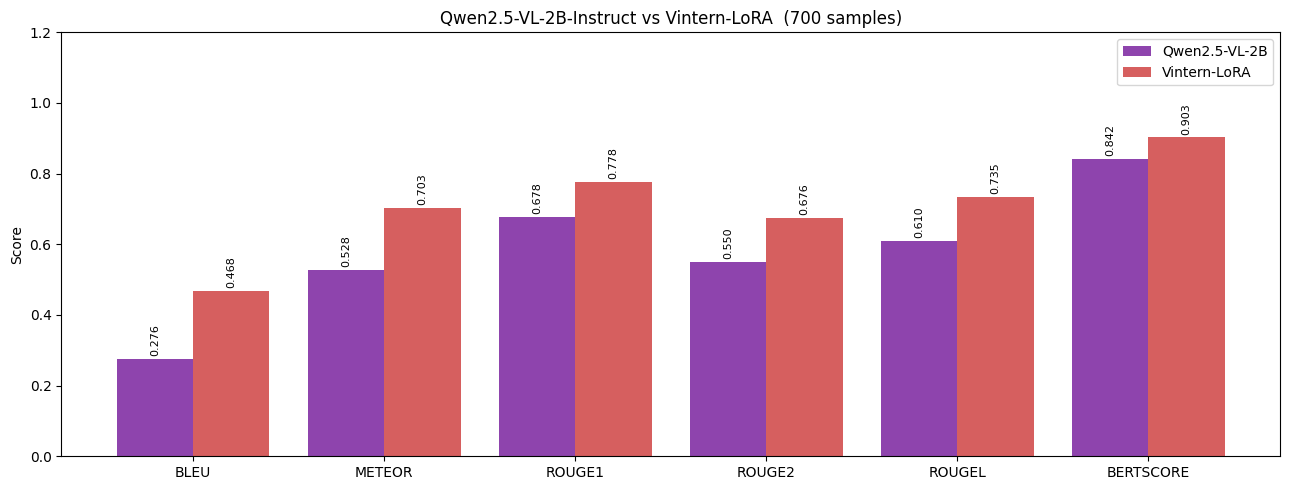

Saved chart: /kaggle/working/eval_qwen25vl_vs_vintern_lora.png


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

all_results = {
    'Qwen2.5-VL-2B': (df_qwen,    avg_qwen),
    'Vintern-LoRA':   (df_vintern, avg_vintern),
}

# Bang summary
rows = []
for mname, (_, avg) in all_results.items():
    row = {'Model': mname}
    for m in METRICS:
        row[m.upper()] = round(avg.get(m, 0.0), 4)
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index('Model')

def highlight_best(s):
    return ['background-color: #d4edda; font-weight: bold'
            if v == s.max() else '' for v in s]

def highlight_worst(s):
    return ['background-color: #f8d7da'
            if v == s.min() else '' for v in s]

print(f'KET QUA ({EVAL_TOTAL} samples | Xanh = cao nhat | Do = thap nhat)\n')
display(summary_df.style.apply(highlight_best).apply(highlight_worst))

csv_summary = KAGGLE_WORKING / 'eval_qwen25vl_vs_vintern_lora.csv'
summary_df.reset_index().to_csv(str(csv_summary), index=False, encoding='utf-8')
print(f'Saved: {csv_summary}')

# Bieu do bar
n      = len(all_results)
x      = np.arange(len(METRICS))
width  = 0.8 / n
colors = ['#8e44ad', '#d65f5f']   # tim cho Qwen, do cho Vintern-LoRA

fig, ax = plt.subplots(figsize=(13, 5))
for idx, (mname, (_, avg)) in enumerate(all_results.items()):
    offset = idx * width - (n - 1) * width / 2
    vals   = [avg.get(m, 0.0) for m in METRICS]
    bars   = ax.bar(x + offset, vals, width, label=mname, color=colors[idx])
    ax.bar_label(bars, fmt='%.3f', padding=2, fontsize=8, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels([m.upper() for m in METRICS], fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.2)
ax.set_title(f'Qwen2.5-VL-2B-Instruct vs Vintern-LoRA  ({EVAL_TOTAL} samples)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()

img_path = KAGGLE_WORKING / 'eval_qwen25vl_vs_vintern_lora.png'
plt.savefig(str(img_path), dpi=150)
plt.show()
print(f'Saved chart: {img_path}')


## Cell 11 — Phân tích per-sample (delta Qwen - Vintern)


In [11]:
import pandas as pd

df_q = df_qwen[['id', 'question', 'ground_truth', 'response'] + METRICS].copy()
df_v = df_vintern[['id'] + [m for m in METRICS if m in df_vintern.columns]].copy()

df_merged = df_q.merge(df_v, on='id', suffixes=('_qwen', '_vintern'))
print(f'Merged: {len(df_merged)} samples')

for m in METRICS:
    cq, cv = f'{m}_qwen', f'{m}_vintern'
    if cq in df_merged.columns and cv in df_merged.columns:
        df_merged[f'delta_{m}'] = df_merged[cq] - df_merged[cv]

print('\nTop 10 Qwen2.5-VL vuot troi (delta BERTScore):')
display(df_merged.nlargest(10, 'delta_bertscore')
        [['id', 'question', 'delta_bleu', 'delta_meteor', 'delta_bertscore']])

print('\nTop 10 Qwen2.5-VL kem hon (delta BERTScore):')
display(df_merged.nsmallest(10, 'delta_bertscore')
        [['id', 'question', 'delta_bleu', 'delta_meteor', 'delta_bertscore']])

merged_csv = KAGGLE_WORKING / 'debug_qwen25vl_vs_vintern_merged.csv'
df_merged.to_csv(str(merged_csv), index=False, encoding='utf-8')
print(f'Saved: {merged_csv}')


Merged: 700 samples

Top 10 Qwen2.5-VL vuot troi (delta BERTScore):


,id,question,delta_bleu,delta_meteor,delta_bertscore
480,6a5647a97ec9a1aaa4f5,Tỷ lệ phần trăm phụ nữ trong dân số Lào vào kh...,0.345605,0.544089,0.170328
34,21d1e48876dcc18cc326,Tỷ lệ dân số nông thôn ở quần đảo Faroe vào nă...,0.123513,0.487334,0.155254
555,d07a3fd6121147538f05_q1,Điểm số năng lực cạnh tranh của Quảng Ninh cao...,0.354966,0.373596,0.106545
460,251afe543da23b6617bf,Trò chơi nào có doanh thu cao nhất và doanh th...,0.337002,0.386065,0.098640
428,45c510fde5bb1624f285,Vào khoảng thời gian nào trong ngày có tỷ lệ n...,0.148950,0.124881,0.082738
329,dbbe9855d63a864e915c,Công ty nào có doanh thu cao nhất và doanh thu...,0.401847,0.496875,0.081161
425,af8a5412e1af28ac4ba8,Phim Star Wars nào có doanh thu cao nhất?,0.421443,0.401010,0.080804
173,9c2ade3a00204edd816f,Trang web du lịch nào có phần trăm truy cập ca...,0.587509,0.249385,0.079939
131,26ee9c827a1b48f05914,"Vào năm 1966, quốc gia nào có tỷ lệ phụ thuộc ...",0.056947,0.125655,0.077986
404,c9393a46fc9faac6ca4d,Năm nào có tỷ lệ trẻ em thừa cân cao nhất ở cả...,0.306902,0.162601,0.067233



Top 10 Qwen2.5-VL kem hon (delta BERTScore):


,id,question,delta_bleu,delta_meteor,delta_bertscore
346,7b824d6d07b47c752d4f,Có bao nhiêu phần trăm người được khảo sát cho...,-0.999986,-0.906203,-0.369064
337,6854fe59665779c0fb8b,Thành phố đô thị số 8 có khoảng bao nhiêu dân số?,-0.660633,-0.881944,-0.368118
240,e7f898f314f5fc5e3a09,Năm nào có tỷ lệ người lao động nam làm việc b...,-0.999917,-0.967640,-0.363608
69,681cbe492a563eb2ab17,Năm nào xuất khẩu của Sudan với các nền kinh t...,-0.787779,-0.804814,-0.363271
445,d9c3b82f0fcc861a6fad,Năm nào có doanh thu cao nhất trong khoảng thờ...,-0.631552,-0.700013,-0.346728
400,e1a30db8eaac218d03d6,Năm nào Dominica có cán cân thanh toán cao nhấ...,-0.576171,-0.686470,-0.343525
104,cd4eca0f5f8702906eee,Tỷ lệ giới tính nam ở độ tuổi 30 vào năm 1960 ...,-0.111140,-0.194444,-0.342084
57,34f3493f5e4892163482,Năm nào xuất khẩu hàng hóa của New Zealand đạt...,-0.728492,-0.814721,-0.339044
167,e048f20d4038e1c795c5,Năm nào cán cân thương mại của Puerto Rico cao...,-0.365561,-0.716456,-0.325405
64,6aa44eb767f5f41b2fc9,"Năm 1999, quốc gia nào có thời gian bắt buộc đ...",-0.542377,-0.852834,-0.294769


Saved: /kaggle/working/debug_qwen25vl_vs_vintern_merged.csv


## Cell 12 — Histogram phân phối score


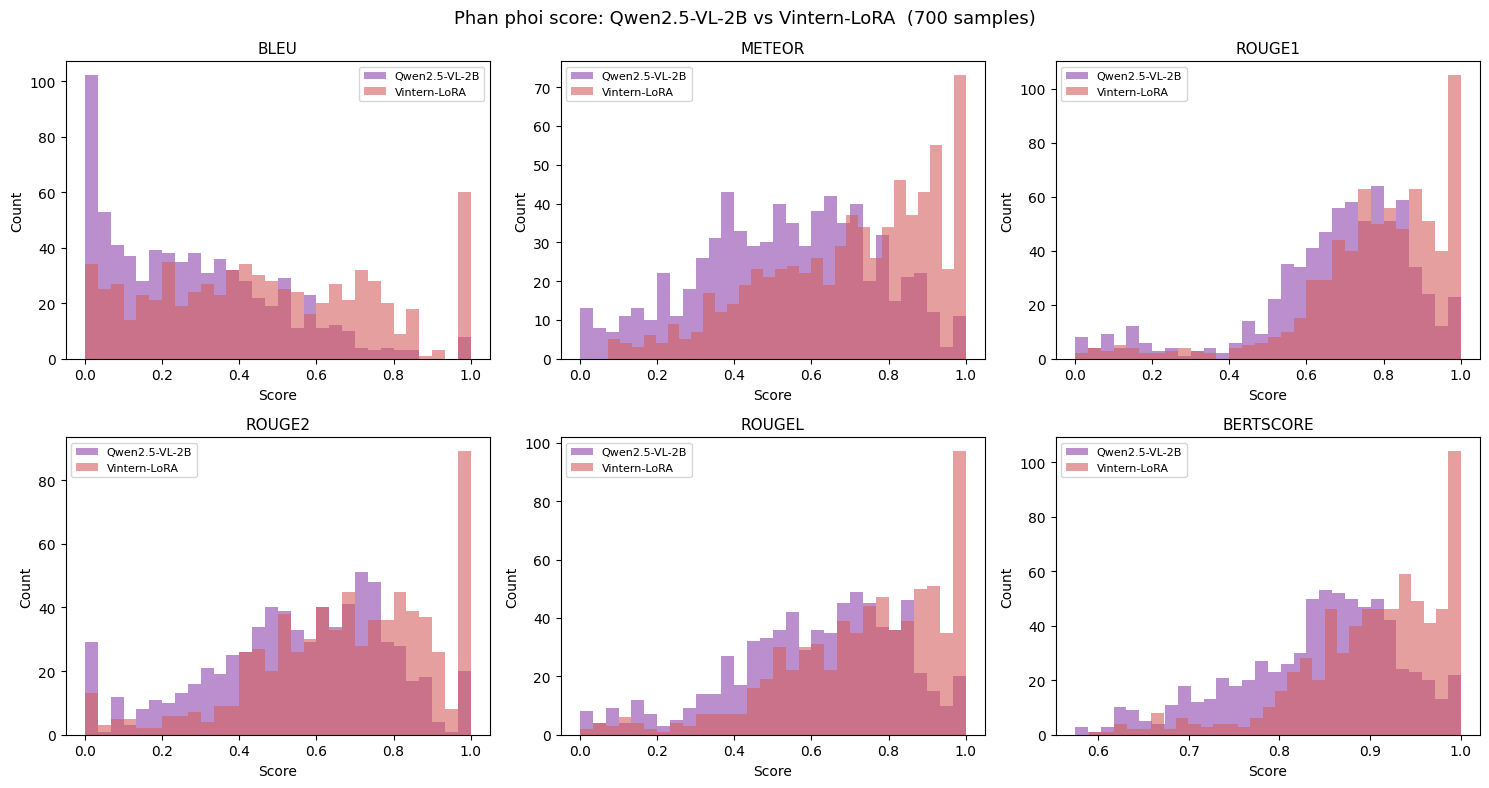

Saved: /kaggle/working/histogram_qwen25vl_vs_vintern_lora.png


In [12]:
import matplotlib.pyplot as plt

color_map = {'Qwen2.5-VL-2B': '#8e44ad', 'Vintern-LoRA': '#d65f5f'}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, m in enumerate(METRICS):
    ax    = axes[i]
    col_q = f'{m}_qwen'
    col_v = f'{m}_vintern'
    if col_q in df_merged.columns:
        ax.hist(df_merged[col_q], bins=30, alpha=0.6,
                color=color_map['Qwen2.5-VL-2B'], label='Qwen2.5-VL-2B')
    if col_v in df_merged.columns:
        ax.hist(df_merged[col_v], bins=30, alpha=0.6,
                color=color_map['Vintern-LoRA'], label='Vintern-LoRA')
    ax.set_title(m.upper(), fontsize=11)
    ax.set_xlabel('Score')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle(
    f'Phan phoi score: Qwen2.5-VL-2B vs Vintern-LoRA  ({len(df_merged)} samples)',
    fontsize=13,
)
plt.tight_layout()

hist_path = KAGGLE_WORKING / 'histogram_qwen25vl_vs_vintern_lora.png'
plt.savefig(str(hist_path), dpi=150)
plt.show()
print(f'Saved: {hist_path}')
